# SCOPe family assignment benchmark

## Description

Using viral subset of the SCOPe dataset, we assess the performance of ESM3Di versus ProstT5 in assigning domains to the correct category.

This is a reproduced version of the identical benchmark used in Foldseek paper, therefore please refer to the paper ([link](https://www.nature.com/articles/s41587-023-01773-0)) for detailed description of the benchmark (Methods - SCOPe benchmark).

---

## SCOPe Dataset preparation

### Download SCOPe40 dataset

In [3]:
from pathlib import Path
import os

#create data directory if it doesn't exist
os.makedirs("/mnt/data1/scop_benchmark", exist_ok=True)
DATAPATH = Path("/mnt/data1/scop_benchmark").resolve()

os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /mnt/data1/scop_benchmark


In [ ]:
%%bash

mkdir -p $DATAPATH/scope

wget --no-check-certificate -q -O $DATAPATH/scope/dir.des.scope.txt \
	"https://scop.berkeley.edu/downloads/parse/dir.des.scope.2.08-stable.txt"
wget --no-check-certificate -q -O $DATAPATH/scope/dir.cla.scope.txt \
	"https://scop.berkeley.edu/downloads/parse/dir.cla.scope.2.08-stable.txt"

### Parse taxonomy information to obtain viral subset of the SCOPe40 dataset

#### Obtain NCBI taxdump files

In [7]:
%%bash
mkdir -p $DATAPATH/ncbi
wget -q -O $DATAPATH/ncbi/taxdump.tar.gz "ftp://ftp.ncbi.nih.gov/pub/taxonomy/taxdump.tar.gz"
tar -xzf $DATAPATH/ncbi/taxdump.tar.gz -C $DATAPATH/ncbi

#### Parse taxonomy files and identify viral entries

In [ ]:
%%bash
awk -F'\t' '$7~/scientific/' $DATAPATH/ncbi/names.dmp > $DATAPATH/ncbi/scientific_names.dmp
awk '\
	BEGIN{FS="\t"; OFS="\t"} FNR==1{FC++} \
	FC==1{p[$1]=$3;r[$1]=$5;next} \
	FC==2{n[$1]=$3;next} \
	{x="";while($2>1){x=x?n[$2]","x:n[$2];$2=p[$2]} print $1,x}' \
	$DATAPATH/ncbi/nodes.dmp $DATAPATH/ncbi/scientific_names.dmp \
	<(awk -F'\t|=|,| |]' 'NR==FNR{if($2=="sp")f[$1]=$(NF-1);next} FNR>4 {print $1 "\t" f[$17]}' \
	$DATAPATH/scope/dir.des.scope.txt $DATAPATH/scope/dir.cla.scope.txt) \
	> $DATAPATH/scope/scope40_taxonomy.tsv
awk -F'\t|,' '$2~/Viruses/ {print $1}' $DATAPATH/scope/scope40_taxonomy.tsv > $DATAPATH/scope/scope40_viral_ids.txt
echo "$(wc -l < $DATAPATH/scope/scope40_viral_ids.txt) viral entries identified in the SCOPe40 dataset"

16272 viral entries identified in the SCOPe40 dataset


### Create viral subset of the SCOPe40 dataset

#### Download PDB files

In [15]:
%%bash

mkdir -p $DATAPATH/scope/pdb_viral


In [ ]:
%%bash
cat $DATAPATH/scope/scope40_viral_ids.txt | while read id; do
	echo -e "https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/${id:2:2}/${id}.ent\n\tout=pdb_viral/${id}.pdb"
done > $DATAPATH/scope/scope40_aria2c.txt



In [30]:
%%bash
#read some lines from the aria2c input file to verify the format

head -n 10 $DATAPATH/scope/scope40_aria2c.txt

https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/ez/d2ezla_.ent
	out=pdb_viral/d2ezla_.pdb
https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/ez/d2ezka_.ent
	out=pdb_viral/d2ezka_.pdb
https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/ez/d2ezia_.ent
	out=pdb_viral/d2ezia_.pdb
https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/ez/d2ezha_.ent
	out=pdb_viral/d2ezha_.pdb
https://scop.berkeley.edu/downloads/pdbstyle/pdbstyle-2.08/h8/d1h8ac1.ent
	out=pdb_viral/d1h8ac1.pdb


In [ ]:
%%bash
cd $DATAPATH/scope
aria2c -i $DATAPATH/scope/scope40_aria2c.txt -x 16 -j 16 --check-certificate=false --quiet=false

In [33]:
%%bash
#count the number of viral entries with successfully downloaded PDB files
ls $DATAPATH/scope/pdb_viral/* | wc -l

18089


#### Remove entries with multiple models

In [ ]:
%%bash
mkdir -p $DATAPATH/scope/pdb_viral_multi
cat $DATAPATH/scope/scope40_viral_ids.txt | while read id; do
	CNT=$(grep -m2 MODEL $DATAPATH/scope/pdb_viral/${id}.pdb | wc -l)
	# if count is greater than 1, move the file to a separate folder
	if [ $CNT -gt 1 ]; then
		mv $DATAPATH/scope/pdb_viral/${id}.pdb $DATAPATH/scope/pdb_viral_multi/${id}.pdb
	fi
done

In [36]:
%%bash
mkdir -p $DATAPATH/foldseek
foldseek createdb $DATAPATH/scope/pdb_viral $DATAPATH/foldseek/scope40_viral

createdb /mnt/data1/scop_benchmark/scope/pdb_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Output file: /mnt/data1/scop_benchmark/foldseek/scope40_viral
[=================================================================] 17.79K 3s 84ms
Time for merging to scope40_viral_ss: 0h 0m 0s 18ms
Time for merging to scope40_viral_h: 0h 0m 0s 7ms
Time for merging to scope40_viral_ca: 0h 0m 0s 38ms
Time for merging to scope40_viral: 0h 0m 0s 12ms
Ignore 4 out of 21448.
Too short: 0, incorrect: 1, not proteins: 3.
Time 

### Create FASTA files of the viral SCOPe40 dataset

In [37]:
%%bash
foldseek base:convert2fasta $DATAPATH/foldseek/scope40_viral $DATAPATH/scope/scope40_viral_aa.fa
foldseek base:lndb $DATAPATH/foldseek/scope40_viral_h $DATAPATH/foldseek/scope40_viral_ss_h
foldseek base:convert2fasta $DATAPATH/foldseek/scope40_viral_ss $DATAPATH/scope/scope40_viral_3di.fa

convert2fasta /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/scope/scope40_viral_aa.fa 

MMseqs Version:	10.941cd33
Use header DB	false
Verbosity    	3

Start writing file to /mnt/data1/scop_benchmark/scope/scope40_viral_aa.fa
Time for processing: 0h 0m 0s 15ms
lndb /mnt/data1/scop_benchmark/foldseek/scope40_viral_h /mnt/data1/scop_benchmark/foldseek/scope40_viral_ss_h 

MMseqs Version:	10.941cd33
Verbosity	3

Time for processing: 0h 0m 0s 0ms
convert2fasta /mnt/data1/scop_benchmark/foldseek/scope40_viral_ss /mnt/data1/scop_benchmark/scope/scope40_viral_3di.fa 

MMseqs Version:	10.941cd33
Use header DB	false
Verbosity    	3

Start writing file to /mnt/data1/scop_benchmark/scope/scope40_viral_3di.fa
Time for processing: 0h 0m 0s 14ms


---

## 3Di prediction with ProstT5 and ESM3Di

#### Predict 3Di with ProstT5

In [38]:
%%bash
foldseek databases ProstT5 $DATAPATH/prostt5_weights $DATAPATH/tmp
rm -rf $DATAPATH/tmp
foldseek createdb $DATAPATH/scope/scope40_viral_aa.fa $DATAPATH/foldseek/scope40_viral_prostt5 --gpu 1 --prostt5-model $DATAPATH/prostt5_weights

Create directory /mnt/data1/scop_benchmark/tmp
databases ProstT5 /mnt/data1/scop_benchmark/prostt5_weights /mnt/data1/scop_benchmark/tmp 

MMseqs Version:              	10.941cd33
Tsv                          	false
Force restart with latest tmp	false
Remove temporary files       	false
Compressed                   	0
Threads                      	32
Verbosity                    	3


03/29 15:16:59 [NOTICE] Downloading 1 item(s)

03/29 15:16:59 [NOTICE] CUID#7 - Redirecting to https://steineggerlab.s3.amazonaws.com/foldseek/prostt5-f16-gguf.tar.gz

03/29 15:17:00 [NOTICE] CUID#9 - Redirecting to https://steineggerlab.s3.amazonaws.com/foldseek/prostt5-f16-gguf.tar.gz

03/29 15:17:00 [NOTICE] CUID#10 - Redirecting to https://steineggerlab.s3.amazonaws.com/foldseek/prostt5-f16-gguf.tar.gz

03/29 15:17:00 [NOTICE] CUID#11 - Redirecting to https://steineggerlab.s3.amazonaws.com/foldseek/prostt5-f16-gguf.tar.gz

03/29 15:17:00 [NOTICE] CUID#12 - Redirecting to https://steineggerlab.s3.amazon

### Predict 3Di representations with ESM3Di

In [ ]:
%%bash
MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
ESM3DI_DIR='/home/dmoi/projects/ESM3di/benchmark'
cd $ESM3DI_DIR

python -m esm3di.fastas2foldseekdb \
	--aa-fasta $DATAPATH/scope/scope40_viral_aa.fa  \
	--model-ckpt "$MODEL_CKPT" \
	--output-db "$DATAPATH/foldseek/scope40_viral_esm3di" \
	--keep-fastas

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /mnt/data1/scop_benchmark/scope/scope40_viral_aa.fa...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using 2 GPU(s) for inference on 21445 sequences


Multi-GPU inference:   0%|          | 0/2 [00:05<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processed 40/21445 sequences
Processed 80/21445 sequences
Processed 120/21445 sequences
Processed 160/21445 sequences
Processed 200/21445 sequences
Processed 240/21445 sequences
Processed 280/21445 sequences
Processed 320/21445 sequences
Processed 360/21445 sequences
Processed 400/21445 sequences
Processed 440/21445 sequences
Processed 480/21445 sequences
Processed 520/21445 sequences
Processed 560/21445 sequences
Processed 600/21445 sequences
Processed 640/21445 sequences
Processed 680/21445 sequences
Processed 720/21445 sequences
Processed 760/21445 sequences
Processed 800/21445 sequences
Processed 840/21445 sequences
Processed 880/21445 sequences
Processed 920/21445 sequences
Processed 960/21445 sequences
Processed 1000/21445 sequences
Processed 1040/21445 sequences
Processed 1080/21445 sequences
Processed 1120/21445 sequences
Processed 1160/21445 sequences
Processed 1200/21445 sequences
Processed 1240/21445 sequences
Processed 1280/21445 sequences
Processed 1320/21445 sequences
Pro

## Foldseek search and parsing results

### Target 1. ProstT5

#### All-vs-all Foldseek search

In [ ]:
%%bash
foldseek search --exhaustive-search -e INF \
	$DATAPATH/foldseek/scope40_viral_prostt5 $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_prostt5_aln $DATAPATH/tmp
foldseek convertalis --format-output query,target \
	$DATAPATH/foldseek/scope40_viral_prostt5 $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_prostt5_aln $DATAPATH/scope/scope40_viral_prostt5_aln.tsv

Create directory /mnt/data1/scop_benchmark/tmp
search --exhaustive-search -e INF /mnt/data1/scop_benchmark/foldseek/scope40_viral_prostt5 /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral_prostt5_aln /mnt/data1/scop_benchmark/tmp 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit order                  	0
TMalign fast                       	1
Preload mode                       	0
Threads                            	32
Verbosity                          	3
LDDT threshold                     	0
Sort by structure bit score        	1
Alignment type                     	2
Exact TMscore                      	0
Subs

#### Calculate fraction of correct assignments up to first false positive

In [ ]:
import polars as pl

def calc_fp_rates(aln_class_path, method_name):
	inp = pl.read_csv(
		aln_class_path,
		separator='\t',
		has_header=False,
		new_columns=['qid', 'tid', 'qfo', 'qsf', 'qfa', 'tfo', 'tsf', 'tfa'],
	)

	# 1) assign distance along each query group
	inp = inp.with_columns([
		pl.arange(0, pl.len()).over('qid').alias('rid'),
	])

	# 2) convert condition to numeric status
	inp = inp.with_columns([
		(pl.col('qfo') != pl.col('tfo')).cast(pl.Int8).alias('is_wrong_fold'),
		(pl.col('qfo') == pl.col('tfo')).cast(pl.Int8).alias('is_same_fold'),
		(pl.col('qsf') == pl.col('tsf')).cast(pl.Int8).alias('is_same_super'),
		(pl.col('qfa') == pl.col('tfa')).cast(pl.Int8).alias('is_same_family'),
	])

	# 3) compute overflow flag: true once wrong fold seen for each query
	inp = inp.with_columns([
		(pl.col('is_wrong_fold').cum_sum().over('qid').gt(0)).cast(pl.Int8).alias('seen_fp'),
	])

	# 4) compute per-hit classes
	inp = inp.with_columns([
		((pl.col('qfo') == pl.col('tfo')) & (pl.col('qsf') != pl.col('tsf'))).cast(pl.Int32).alias('count_fold'),
		((pl.col('qfo') == pl.col('tfo')) & (pl.col('qsf') == pl.col('tsf')) & (pl.col('qfa') != pl.col('tfa'))).cast(pl.Int32).alias('count_super'),
		((pl.col('qfo') == pl.col('tfo')) & (pl.col('qsf') == pl.col('tsf')) & (pl.col('qfa') == pl.col('tfa'))).cast(pl.Int32).alias('count_family'),
	])

	# 5) fold/super/fam if not FP-flagged for this row
	inp = inp.with_columns([
		(pl.col('count_fold') * (1 - pl.col('seen_fp'))).alias('fold_tp'),
		(pl.col('count_super') * (1 - pl.col('seen_fp'))).alias('super_tp'),
		(pl.col('count_family') * (1 - pl.col('seen_fp'))).alias('family_tp'),
	])

	# aggregates per qid
	agg = inp.group_by('qid', maintain_order=True).agg([
		pl.col('fold_tp').sum().alias('focnt'),
		pl.col('count_fold').sum().alias('fotot'),
		pl.col('super_tp').sum().alias('sfcnt'),
		pl.col('count_super').sum().alias('sftot'),
		pl.col('family_tp').sum().alias('facnt'),
		pl.col('count_family').sum().alias('fatot'),
	])

	agg = agg.with_columns([
		pl.when(pl.col('fotot') == 0).then(1).otherwise(pl.col('fotot')).alias('fotot'),
		pl.when(pl.col('sftot') == 0).then(1).otherwise(pl.col('sftot')).alias('sftot'),
		pl.when(pl.col('fatot') == 0).then(1).otherwise(pl.col('fatot')).alias('fatot'),
	])

	agg = agg.with_columns([
		(pl.col('focnt') / pl.col('fotot')).alias('fofrac'),
		(pl.col('sfcnt') / pl.col('sftot')).alias('sfrac'),
		(pl.col('facnt') / pl.col('fatot')).alias('fafrac'),
	])

	agg.select(['qid', 'focnt', 'fotot', 'fofrac']).write_csv(str(DATAPATH / f'scope/{method_name}_fol.tsv'), separator='\t', include_header=False)
	agg.select(['qid', 'sfcnt', 'sftot', 'sfrac']).write_csv(str(DATAPATH / f'scope/{method_name}_sup.tsv'), separator='\t', include_header=False)
	agg.select(['qid', 'facnt', 'fatot', 'fafrac']).write_csv(str(DATAPATH / f'scope/{method_name}_fam.tsv'), separator='\t', include_header=False)



### Target 2. Foldseek

#### All-vs-all Foldseek search

In [ ]:
%%bash
foldseek search --exhaustive-search -e INF \
	$DATAPATH/foldseek/scope40_viral $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_foldseek_aln $DATAPATH/tmp
foldseek convertalis --format-output query,target \
	$DATAPATH/foldseek/scope40_viral $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_foldseek_aln $DATAPATH/scope/scope40_viral_foldseek_aln.tsv

search --exhaustive-search -e INF /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral_foldseek_aln /mnt/data1/scop_benchmark/tmp 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit order                  	0
TMalign fast                       	1
Preload mode                       	0
Threads                            	32
Verbosity                          	3
LDDT threshold                     	0
Sort by structure bit score        	1
Alignment type                     	2
Exact TMscore                      	0
Substitution matrix                	aa:3di.out,nucl:3di.ou

### Target 3. MMseqs2

#### All-vs-all MMseqs2 search

In [ ]:
%%bash
# create fake prefilter file
foldseek base:tsv2db --output-dbtype 7 \
	<(awk 'END {for(i=0;i<NR;i++) for(j=0;j<NR;j++) print i "\t" j}' $DATAPATH/foldseek/scope40_viral.index) \
	$DATAPATH/foldseek/scope40_viral_mmseqs_pref
foldseek base:align -e INF \
	$DATAPATH/foldseek/scope40_viral $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_mmseqs_pref \
	$DATAPATH/foldseek/scope40_viral_mmseqs_aln
foldseek base:convertalis --format-output query,target \
	$DATAPATH/foldseek/scope40_viral $DATAPATH/foldseek/scope40_viral \
	$DATAPATH/foldseek/scope40_viral_mmseqs_aln $DATAPATH/scope/scope40_viral_mmseqs_aln.tsv

tsv2db --output-dbtype 7 /dev/fd/63 /mnt/data1/scop_benchmark/foldseek/scope40_viral_mmseqs_pref 

MMseqs Version:           	10.941cd33
Output database type      	7
Compressed                	0
Verbosity                 	3

Output database type: Prefilter
Time for merging to scope40_viral_mmseqs_pref: 0h 0m 0s 8ms
Time for processing: 0h 3m 49s 572ms
align -e INF /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral /mnt/data1/scop_benchmark/foldseek/scope40_viral_mmseqs_pref /mnt/data1/scop_benchmark/foldseek/scope40_viral_mmseqs_aln 

MMseqs Version:           	10.941cd33
Substitution matrix       	aa:3di.out,nucl:3di.out
Add backtrace             	false
Alignment mode            	0
Alignment mode            	0
E-value threshold         	inf
Seq. id. threshold        	0
Min alignment length      	0
Seq. id. mode             	0
Alternative alignments    	0
Coverage threshold        	0
Coverage mode             	0
Max sequence length       	

### Target 4. ESM3Di



In [ ]:
%%bash
foldseek search --exhaustive-search -e INF \
	$DATAPATH/foldseek/scope40_viral_esm3di $DATAPATH/foldseek/scope40_viral_esm3di \
	$DATAPATH/foldseek/scope40_viral_esm3di_aln $DATAPATH/tmp
foldseek convertalis --format-output query,target \
	$DATAPATH/foldseek/scope40_viral_esm3di $DATAPATH/foldseek/scope40_viral_esm3di \
	$DATAPATH/foldseek/scope40_viral_esm3di_aln $DATAPATH/scope/scope40_viral_esm3di_aln.tsv

search --exhaustive-search -e INF /mnt/data1/scop_benchmark/foldseek/scope40_viral_esm3di /mnt/data1/scop_benchmark/foldseek/scope40_viral_esm3di /mnt/data1/scop_benchmark/foldseek/scope40_viral_esm3di_aln /mnt/data1/scop_benchmark/tmp 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit order                  	0
TMalign fast                       	1
Preload mode                       	0
Threads                            	32
Verbosity                          	3
LDDT threshold                     	0
Sort by structure bit score        	1
Alignment type                     	2
Exact TMscore                      	0
Substitution matrix                	aa:3di.out

#### Assign fold/superfamily/family information

In [11]:
import polars as pl

# load SCOPe class map and skip the 4-line header from dir.cla.scope.txt
cla = pl.read_csv(
	DATAPATH / 'scope/dir.cla.scope.txt',
	separator='\t',
	has_header=False,
	new_columns=['id', 'parent', 'something', 'class'],
	skip_rows=4,
)

cla = cla.with_columns([
	pl.col('class').str.split('.').list.get(1).alias('fo'),
	pl.col('class').str.split('.').list.get(2).alias('sf'),
	pl.col('class').str.split('.').list.get(3).alias('fa'),
])

cla = cla.select(['id', 'fo', 'sf', 'fa'])

# function to make classified alignment table
def compute_aln_class(aln_tsv, output_tsv):
	aln = pl.read_csv(
		aln_tsv,
		separator='\t',
		has_header=False,
		new_columns=['qid', 'tid'],
	)
	work = aln.join(cla, left_on='qid', right_on='id', how='left')
	work = work.rename({'fo':'qfo', 'sf':'qsf', 'fa':'qfa'})
	work = work.join(cla, left_on='tid', right_on='id', how='left')
	work = work.rename({'fo':'tfo', 'sf':'tsf', 'fa':'tfa'})

	work.select(['qid', 'tid', 'qfo', 'qsf', 'qfa', 'tfo', 'tsf', 'tfa']).write_csv(
		str(output_tsv),
		separator='\t',
		include_header=False,
	)
	print(f"Classification completed for {aln_tsv}, output written to {output_tsv}")

# compute for all methods
datasets = {
	'scope40_viral_prostt5': 'scope40_viral_prostt5_aln.tsv',
	'scope40_viral_foldseek': 'scope40_viral_foldseek_aln.tsv',
	'scope40_viral_mmseqs': 'scope40_viral_mmseqs_aln.tsv',
	'scope40_viral_esm3di': 'scope40_viral_esm3di_aln.tsv',
}

for name, aln_file in datasets.items():
	print(f"Processing {name}...")
	if (DATAPATH / 'scope' / f'scope40_viral_{name}_aln_class.tsv').exists():
		print(f"file {DATAPATH / 'scope' / f'scope40_viral_{name}_aln_class.tsv'} already exists, skipping...")
		continue
	compute_aln_class(
		DATAPATH / 'scope' / aln_file,
		DATAPATH / 'scope' / f'scope40_viral_{name}_aln_class.tsv',
	)

Processing scope40_viral_prostt5...
file /mnt/data1/scop_benchmark/scope/scope40_viral_scope40_viral_prostt5_aln_class.tsv already exists, skipping...
Processing scope40_viral_foldseek...
file /mnt/data1/scop_benchmark/scope/scope40_viral_scope40_viral_foldseek_aln_class.tsv already exists, skipping...
Processing scope40_viral_mmseqs...
file /mnt/data1/scop_benchmark/scope/scope40_viral_scope40_viral_mmseqs_aln_class.tsv already exists, skipping...
Processing scope40_viral_esm3di...
file /mnt/data1/scop_benchmark/scope/scope40_viral_scope40_viral_esm3di_aln_class.tsv already exists, skipping...


In [16]:
datasets = {
	'scope40_viral_prostt5': DATAPATH / 'scope/scope40_viral_prostt5_aln_class.tsv',
	'scope40_viral_foldseek': DATAPATH / 'scope/scope40_viral_scope40_viral_foldseek_aln_class.tsv',
	'scope40_viral_mmseqs': DATAPATH / 'scope/scope40_viral_scope40_viral_mmseqs_aln_class.tsv',
	'scope40_viral_esm3di': DATAPATH / 'scope/scope40_viral_esm3di_aln_class.tsv',
}

for method_name, aln_class_path in datasets.items():
	print(f"Calculating FP rates for {method_name}...")
	if not (DATAPATH / 'scope' / f'{method_name}_fol.tsv').exists():
		try:
			calc_fp_rates(aln_class_path, method_name)
		except Exception as e:
			print(f"Error processing {method_name}: {e}")

Calculating FP rates for scope40_viral_prostt5...
Calculating FP rates for scope40_viral_foldseek...
Calculating FP rates for scope40_viral_mmseqs...
Calculating FP rates for scope40_viral_esm3di...


## Parse results and draw AUROC1 curves

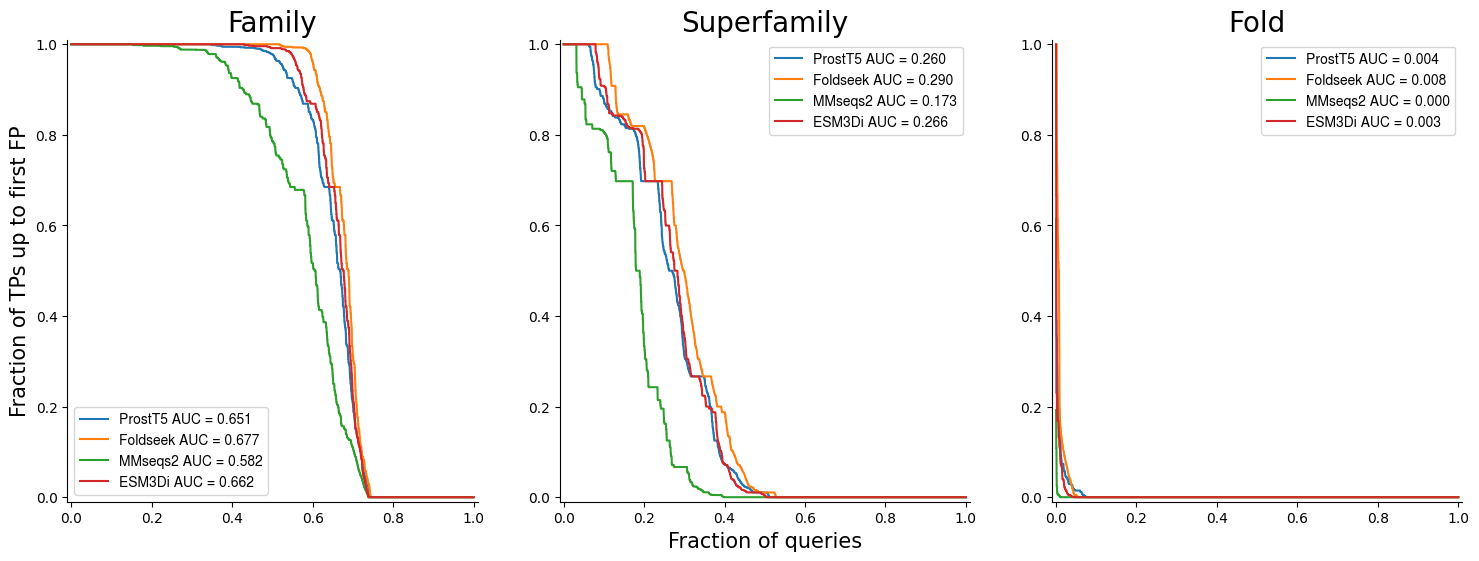

In [17]:
from matplotlib import pyplot as plt

# 1x3 subplots for family/superfamily/fold
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

# sort the file in descending order of 4th column, plot over query
# x-axis: fraction of queries, y-axis: fraction of TP up to first FP
def roc_plot(ax, file, tool):
	with open(file) as f:
		data = [line.strip().split() for line in f]
		data.sort(key=lambda x: float(x[3]), reverse=True)
		x = [1.0*(i+1)/len(data) for i in range(len(data))]
		y = [float(x[3]) for x in data]
		auc = sum(y) / len(y)
		ax.plot(x, y, label=f'{tool} AUC = {auc:.3f}')

# parse family-level results
axs[0].set_title('Family', fontsize=20)
roc_plot(axs[0], DATAPATH / 'scope/scope40_viral_prostt5_fam.tsv', 'ProstT5')
roc_plot(axs[0], DATAPATH / 'scope/scope40_viral_foldseek_fam.tsv', 'Foldseek')
roc_plot(axs[0], DATAPATH / 'scope/scope40_viral_mmseqs_fam.tsv', 'MMseqs2')
roc_plot(axs[0], DATAPATH / 'scope/scope40_viral_esm3di_fam.tsv', 'ESM3Di')

# parse superfamily-level results
axs[1].set_title('Superfamily', fontsize=20)
roc_plot(axs[1], DATAPATH / 'scope/scope40_viral_prostt5_sup.tsv', 'ProstT5')
roc_plot(axs[1], DATAPATH / 'scope/scope40_viral_foldseek_sup.tsv', 'Foldseek')
roc_plot(axs[1], DATAPATH / 'scope/scope40_viral_mmseqs_sup.tsv', 'MMseqs2')
roc_plot(axs[1], DATAPATH / 'scope/scope40_viral_esm3di_sup.tsv', 'ESM3Di')

# parse fold-level results
axs[2].set_title('Fold', fontsize=20)
roc_plot(axs[2], DATAPATH / 'scope/scope40_viral_prostt5_fol.tsv', 'ProstT5')
roc_plot(axs[2], DATAPATH / 'scope/scope40_viral_foldseek_fol.tsv', 'Foldseek')
roc_plot(axs[2], DATAPATH / 'scope/scope40_viral_mmseqs_fol.tsv', 'MMseqs2')
roc_plot(axs[2], DATAPATH / 'scope/scope40_viral_esm3di_fol.tsv', 'ESM3Di')

axs[1].set_xlabel('Fraction of queries', fontsize=15)
axs[0].set_ylabel('Fraction of TPs up to first FP', fontsize=15)

for ax in axs:
	# remove top and right spines
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	# set limit to 0 to 1
	ax.set_xlim(-0.01, 1.01)
	ax.set_ylim(-0.01, 1.01)
	# show legend
	ax.legend()
plt.show()
